# emberllm vs llama.cpp — a measured comparison

**Question.** emberllm is a from-scratch, CPU-only LLM inference engine in ~3,300
lines of C11. How does it actually perform against [llama.cpp](https://github.com/ggml-org/llama.cpp),
the reference engine of this genre, on the same hardware, the same models, and
the same measurements?

**Design.** Both engines run the *same upstream weights* (each engine's own
converter and Q8_0 quantizer), on the *same machine*, measured the *same way*
(batch prefill throughput, and single-token decode throughput at a pinned
context depth, mean ± sd over 5 timed repetitions after a warmup). llama.cpp is
a stock release build, not handicapped: its CPU build uses Apple Accelerate,
runtime weight repacking, and its NEON kernels. A Metal (GPU) build is included
as context for what the same hardware does when you don't restrict yourself to
the CPU.

**Honesty rules.** Every performance number in this notebook is computed at
execution time from `bench/results/*.json`, which the benchmark driver wrote
directly from engine output; static facts quoted in prose (line counts, binary
sizes, build times) are recorded in `bench/results/artifacts.json`.
Configurations where emberllm loses are shown with the same prominence as ones
where it wins, and there is a dedicated section on losses. The final section
lists everything that limits the generality of these results.

## 1. Environment

One machine, pinned software versions. The benchmark driver
(`bench/compare_llamacpp.py`) captured this automatically at run time; the run
protocol required a quiet machine (no other busy processes; the one hot
background process found beforehand was stopped first).

In [1]:
import json, os
from pathlib import Path
import pandas as pd

RES = Path("..") / "bench" / "results"
data = json.loads((RES / "results.json").read_text())
env, rows = data["env"], pd.DataFrame(data["results"])
artifacts = json.loads((RES / "artifacts.json").read_text())

pd.set_option("display.float_format", lambda v: f"{v:,.1f}")
env_table = pd.DataFrame([
    ("CPU", env["cpu"]),
    ("Cores", f"{env['cores_performance']} performance + {env['cores_efficiency']} efficiency"),
    ("Memory", f"{int(env['mem_bytes']) // 2**30} GiB"),
    ("OS", f"macOS {env['macos']}"),
    ("Compiler", env["cc_version"]),
    ("Power", "battery (see threats-to-validity §10)" if "Battery" in env.get("power", "") else "AC"),
    ("emberllm commit", env["ember_commit"][:12] + ("  (src/ dirty!)" if env["ember_dirty"] else "")),
    ("emberllm build", env["ember_cflags"]),
    ("llama.cpp version", f"{env.get('llama_cpu_describe','?')} ({env.get('llama_cpu_commit','?')[:12]})"),
    ("llama.cpp CPU build", "cmake -DGGML_METAL=OFF -DCMAKE_BUILD_TYPE=Release (Accelerate ON — stock)"),
    ("llama.cpp Metal build", "cmake -DCMAKE_BUILD_TYPE=Release (stock)"),
    ("Benchmark date", env["date_utc"][:16].replace("T", " ") + " UTC"),
], columns=["", "value"]).set_index("")
env_table

,value
,
CPU,Apple M1 Pro
Cores,6 performance + 2 efficiency
Memory,16 GiB
OS,macOS 26.1
Compiler,Apple clang version 17.0.0 (clang-1700.6.3.2)
Power,battery (see threats-to-validity §10)
emberllm commit,bd59278fcfa7
emberllm build,-std=c11 -O3 -ffast-math -march=native -funrol...
llama.cpp version,b10068 (571d0d540df0)


## 2. What is compared, and why it is fair

Four models, all runnable by both engines, all from identical upstream weights:

| model | source weights | class |
|---|---|---|
| Qwen3-0.6B | `Qwen/Qwen3-0.6B` (HF safetensors) | real chat model, GQA + QK-norm |
| Qwen2.5-0.5B-Instruct | `Qwen/Qwen2.5-0.5B-Instruct` | chat model, GQA + QKV bias |
| SmolLM2-135M-Instruct | `HuggingFaceTB/SmolLM2-135M-Instruct` | small LLaMA-style |
| stories110M | `karpathy/tinyllamas` (llama2.c) | LLaMA-2 arch, TinyStories |

Conversion paths, each engine using **its own** tooling on the **same** source
files (the exact snapshots on disk were byte-identical inputs to both):

- **emberllm:** `tools/convert.py` → fp32 `.ember` → `ember quantize … q8_0`
- **llama.cpp:** `convert_hf_to_gguf.py --outtype f32` → `llama-quantize … Q8_0`
  (stories110M via `llama-convert-llama2c-to-ggml`)

Both engines use the *same* Q8_0 block format (32 weights per block, fp16
scale), so bytes-per-token during decode are essentially equal. One visible
difference in the file-size table below: for **Qwen3-0.6B and stories110M**,
llama.cpp's converters materialize the tied output projection as a separate
tensor, making those two GGUF files larger than their `.ember` counterparts
(for Qwen2.5 and SmolLM2 the sizes essentially match). A converter layout
choice, **not** an engine speed difference — the duplicated copy is only used
for row lookups, not streamed per token.

The comparison is **single-stream, CPU inference** — that is emberllm's entire
scope, and the one llama.cpp configuration it can be compared against
like-for-like. llama.cpp does far more (GPU offload, batching, K-quants,
speculative decoding, a whole ecosystem); §10 keeps that in view.

In [2]:
mf = artifacts["model_files"]
def _sz(p): return f"{mf[p] / 2**20:,.0f} MB"
pd.DataFrame([
    ("Qwen3-0.6B Q8_0",    _sz("models/qwen3-0.6b-q8.ember"),   _sz("models/gguf/qwen3-0.6b-q8_0.gguf")),
    ("Qwen2.5-0.5B Q8_0",  _sz("models/qwen2.5-0.5b-q8.ember"), _sz("models/gguf/qwen2.5-0.5b-q8_0.gguf")),
    ("SmolLM2-135M Q8_0",  _sz("models/smollm2-135m-q8.ember"), _sz("models/gguf/smollm2-135m-q8_0.gguf")),
    ("stories110M Q8_0",   _sz("models/stories110M-q8.ember"),  _sz("models/gguf/stories110M-q8_0.gguf")),
    ("Qwen3-0.6B Q4_0",    _sz("models/qwen3-0.6b-q4.ember"),   _sz("models/gguf/qwen3-0.6b-q4_0.gguf")),
], columns=["model", ".ember file", ".gguf file"]).set_index("model")

,.ember file,.gguf file
model,,
Qwen3-0.6B Q8_0,609 MB,767 MB
Qwen2.5-0.5B Q8_0,505 MB,506 MB
SmolLM2-135M Q8_0,138 MB,138 MB
stories110M Q8_0,111 MB,137 MB
Qwen3-0.6B Q4_0,399 MB,447 MB


## 3. Methodology

Two throughput measurements, deliberately defined so both engines run the same
test:

- **Prefill `ppN`** — process an N-token prompt as one batch; report tok/s.
  This is the "time to first token" regime.
  emberllm: `ember bench --pp N` • llama.cpp: `llama-bench -p N`
- **Decode `tg128 @ dD`** — generate 128 tokens one at a time starting from a
  D-token context; report tok/s. Decode speed falls as context grows (attention
  is linear in context length), so the depth is pinned and stated.
  emberllm: `ember bench --pp D --tg 128` (decode timed separately from the
  prefill that establishes the depth) • llama.cpp: `llama-bench -n 128 -d D`

Both tools use synthetic token streams, run **1 untimed warmup + 5 timed
repetitions**, and report mean ± sample sd. The driver additionally read each
model file once before its block (so neither engine pays first-touch page
faults inside a timed rep), ran everything serially on a quiet machine, and
re-ran the first configuration at the very end as a **drift check** (below).
Thread counts sweep 1–8; this machine has 6 performance + 2 efficiency cores.

What is *not* measured here: sampling overhead (both tools time raw forward
passes), model load time, server/HTTP overhead, batched serving, contexts
beyond 512 tokens, quality beyond §7's spot checks.

In [3]:
main = rows[~rows.engine.str.contains("driftcheck")].copy()
drift = rows[rows.engine.str.contains("driftcheck")]
first = main[(main.engine == "emberllm") & (main.model == drift.iloc[0]["model"]) &
             (main.threads == drift.iloc[0]["threads"]) & (main.quant == drift.iloc[0]["quant"])]
print(f"{len(main)} measurements: "
      f"{sorted(main.engine.unique())} x {sorted(main.model.unique())} x threads {sorted(main.threads.unique())}")
print("\nDrift check — same emberllm config, start of run vs end of run:")
for _, d in drift.iterrows():
    f = first[(first.test == d.test) & (first.n == d.n) & (first.depth == d.depth)].iloc[0]
    delta = 100 * (d.tok_per_sec_mean - f.tok_per_sec_mean) / f.tok_per_sec_mean
    print(f"  {d.test}{d.n}@d{d.depth}: {f.tok_per_sec_mean:.1f} -> {d.tok_per_sec_mean:.1f} tok/s  ({delta:+.1f}%)")

220 measurements: ['emberllm', 'llama.cpp-cpu', 'llama.cpp-metal'] x ['qwen2.5-0.5b', 'qwen3-0.6b', 'smollm2-135m', 'stories110M'] x threads [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]

Drift check — same emberllm config, start of run vs end of run:
  pp512@d0: 57.5 -> 55.7 tok/s  (-3.1%)
  tg128@d512: 31.9 -> 31.1 tok/s  (-2.5%)


## 4. Decode throughput (the number you feel in chat)

Single-stream decode at a 128-token context depth, Q8_0. For each CPU engine
the table shows every thread count; the chart takes each at its **best**
thread count (stated on the bar), which is how each would actually be run —
emberllm ships `--threads auto` for exactly this reason. The Metal build was
measured at one standard configuration (`-ngl 99`, threads are irrelevant to
GPU offload), so its column reads "as measured", not "best of a sweep".

In [4]:
def table(test, n, depth, quant="Q8_0"):
    sub = main[(main.test == test) & (main.n == n) & (main.depth == depth) & (main.quant == quant)
               & (main.engine != "llama.cpp-metal")]
    t = sub.pivot_table(index="threads", columns=["model", "engine"], values="tok_per_sec_mean")
    return t.reindex(sorted(t.columns, key=lambda c: (c[0], c[1])), axis=1)

table("tg", 128, 128)

model   qwen2.5-0.5b               qwen3-0.6b               smollm2-135m  \
engine      emberllm llama.cpp-cpu   emberllm llama.cpp-cpu     emberllm   
threads                                                                    
1               59.8          98.4       43.8          72.1        179.3   
2               73.4         150.2       56.2         108.4        162.1   
4               88.5         168.1       65.1         124.0        152.1   
6               95.0         167.8       64.6         125.3        139.6   
8               89.0         115.7       60.3          78.9        113.5   

model                 stories110M                
engine  llama.cpp-cpu    emberllm llama.cpp-cpu  
threads                                          
1               281.3       214.8         325.8  
2               325.2       228.9         431.1  
4               372.8       227.7         538.9  
6               372.9       193.7         559.4  
8               217.8       169.7         330.7

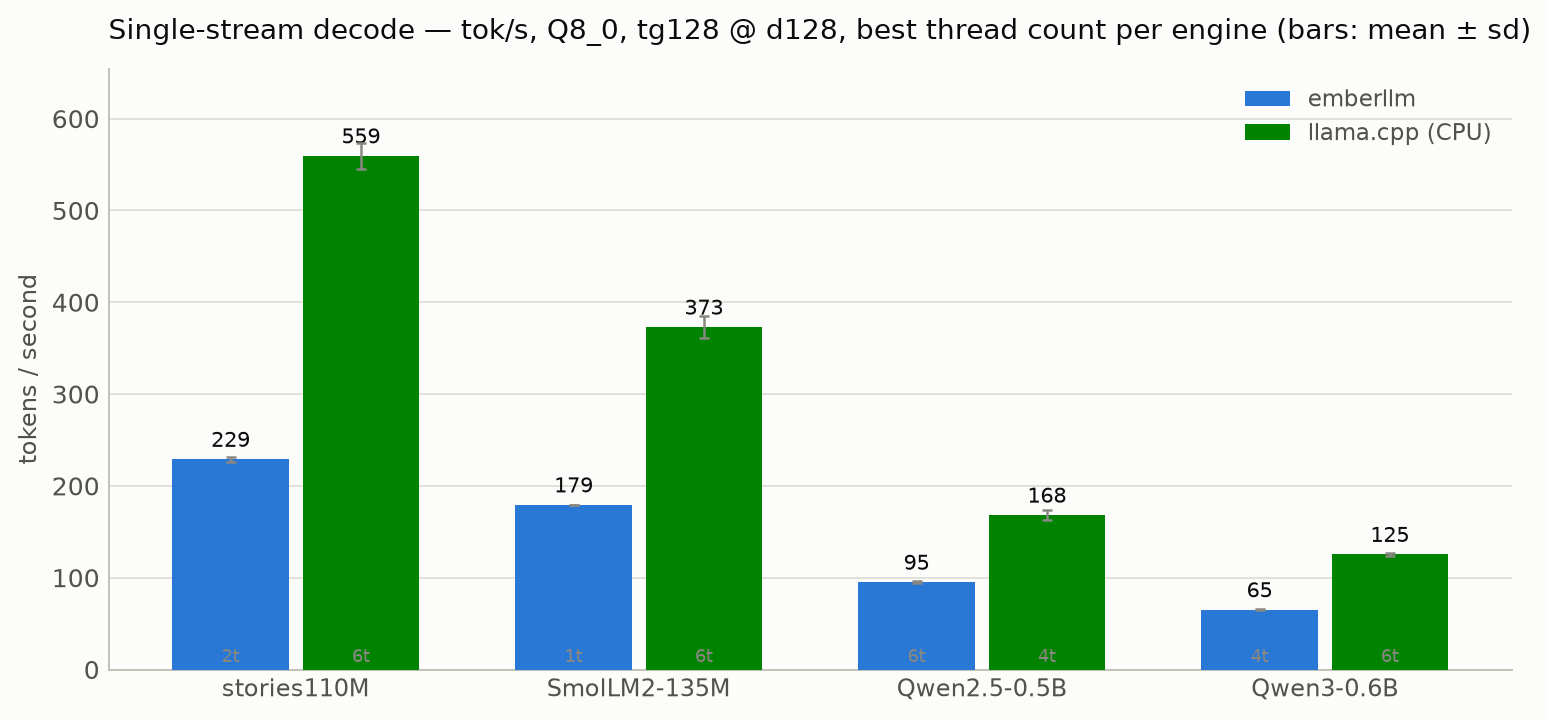

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

THEMES = {
    "light": dict(surface="#fcfcfb", ink="#0b0b0b", sec="#52514e", muted="#898781",
                  grid="#e1e0d9", axis="#c3c2b7",
                  ember="#2a78d6", llama="#008300", metal="#e87ba4"),
    "dark":  dict(surface="#1a1a19", ink="#ffffff", sec="#c3c2b7", muted="#898781",
                  grid="#2c2c2a", axis="#383835",
                  ember="#3987e5", llama="#008300", metal="#d55181"),
}
ENGINES = [("emberllm", "emberllm", "ember"), ("llama.cpp-cpu", "llama.cpp (CPU)", "llama")]
MODELS = ["stories110M", "smollm2-135m", "qwen2.5-0.5b", "qwen3-0.6b"]
LABELS = {"stories110M": "stories110M", "smollm2-135m": "SmolLM2-135M",
          "qwen2.5-0.5b": "Qwen2.5-0.5B", "qwen3-0.6b": "Qwen3-0.6B"}
ASSETS = Path("..") / "docs" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)

def style(ax, t):
    ax.set_facecolor(t["surface"])
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(t["axis"])
    ax.tick_params(colors=t["muted"], labelcolor=t["sec"], length=0)
    ax.yaxis.grid(True, color=t["grid"], linewidth=0.8)
    ax.set_axisbelow(True)

def best(engine, model, test, n, depth, quant="Q8_0"):
    sub = main[(main.engine == engine) & (main.model == model) & (main.test == test)
               & (main.n == n) & (main.depth == depth) & (main.quant == quant)]
    if sub.empty:
        return None
    return sub.loc[sub.tok_per_sec_mean.idxmax()]

def grouped_bars(test, n, depth, title, fname):
    for mode, t in THEMES.items():
        fig, ax = plt.subplots(figsize=(8.6, 4.1), dpi=180)
        fig.patch.set_facecolor(t["surface"])
        style(ax, t)
        w, x0 = 0.34, range(len(MODELS))
        for i, (eng, label, ckey) in enumerate(ENGINES):
            bs = [best(eng, m, test, n, depth) for m in MODELS]
            xs = [x + (i - 0.5) * (w + 0.04) for x in x0]
            ax.bar(xs, [b.tok_per_sec_mean for b in bs], w,
                   yerr=[b.tok_per_sec_stddev for b in bs], error_kw=dict(ecolor=t["muted"], lw=1, capsize=2),
                   color=t[ckey], label=label, zorder=3)
            for x, b in zip(xs, bs):
                ax.annotate(f"{b.tok_per_sec_mean:,.0f}", (x, b.tok_per_sec_mean),
                            xytext=(0, 5), textcoords="offset points", ha="center",
                            fontsize=8.5, color=t["ink"])
                ax.annotate(f"{int(b.threads)}t", (x, 0), xytext=(0, 3), textcoords="offset points",
                            ha="center", fontsize=7, color=t["muted"], zorder=4)
        ax.set_xticks(list(x0), [LABELS[m] for m in MODELS], fontsize=9.5)
        ax.set_ylabel("tokens / second", color=t["sec"], fontsize=9.5)
        ax.set_title(title, color=t["ink"], fontsize=11, pad=12, loc="left")
        ax.legend(frameon=False, labelcolor=t["sec"], fontsize=9)
        ax.margins(y=0.14)
        fig.tight_layout()
        fig.savefig(ASSETS / f"{fname}-{mode}.png", facecolor=t["surface"], bbox_inches="tight")
        if mode == "dark":
            plt.close(fig)

grouped_bars("tg", 128, 128,
             "Single-stream decode — tok/s, Q8_0, tg128 @ d128, best thread count per engine (bars: mean ± sd)",
             "decode")

In [6]:
summ = []
for m in MODELS:
    e, l = best("emberllm", m, "tg", 128, 128), best("llama.cpp-cpu", m, "tg", 128, 128)
    g = best("llama.cpp-metal", m, "tg", 128, 128)
    summ.append((LABELS[m], f"{e.tok_per_sec_mean:,.1f} ({int(e.threads)}t)",
                 f"{l.tok_per_sec_mean:,.1f} ({int(l.threads)}t)",
                 f"{g.tok_per_sec_mean:,.1f}" if g is not None else "—",
                 f"{e.tok_per_sec_mean / l.tok_per_sec_mean:.2f}x"))
pd.DataFrame(summ, columns=["model", "emberllm (best t)", "llama.cpp CPU (best t)",
                            "llama.cpp Metal GPU", "ember / llama CPU"]).set_index("model")

,emberllm (best t),llama.cpp CPU (best t),llama.cpp Metal GPU,ember / llama CPU
model,,,,
stories110M,228.9 (2t),559.4 (6t),436.1,0.41x
SmolLM2-135M,179.3 (1t),372.9 (6t),245.2,0.48x
Qwen2.5-0.5B,95.0 (6t),168.1 (4t),143.0,0.57x
Qwen3-0.6B,65.1 (4t),125.3 (6t),129.9,0.52x


### Thread scaling

Decode on a CPU is memory-bandwidth-bound, so *neither* engine scales decode
linearly with threads — the interesting question is where each peaks and how it
degrades past the performance-core count. Note decode can peak as low as **1
thread** (SmolLM2 on emberllm) and both engines fall off at 8 threads, where
E-cores stall each engine's synchronization. The dashed line is llama.cpp on
the Metal GPU — which, at these model sizes, llama.cpp's own CPU decode
*beats* on three of the four models (GPU dispatch overhead dominates small
kernels; the GPU's real win is prefill, §5).

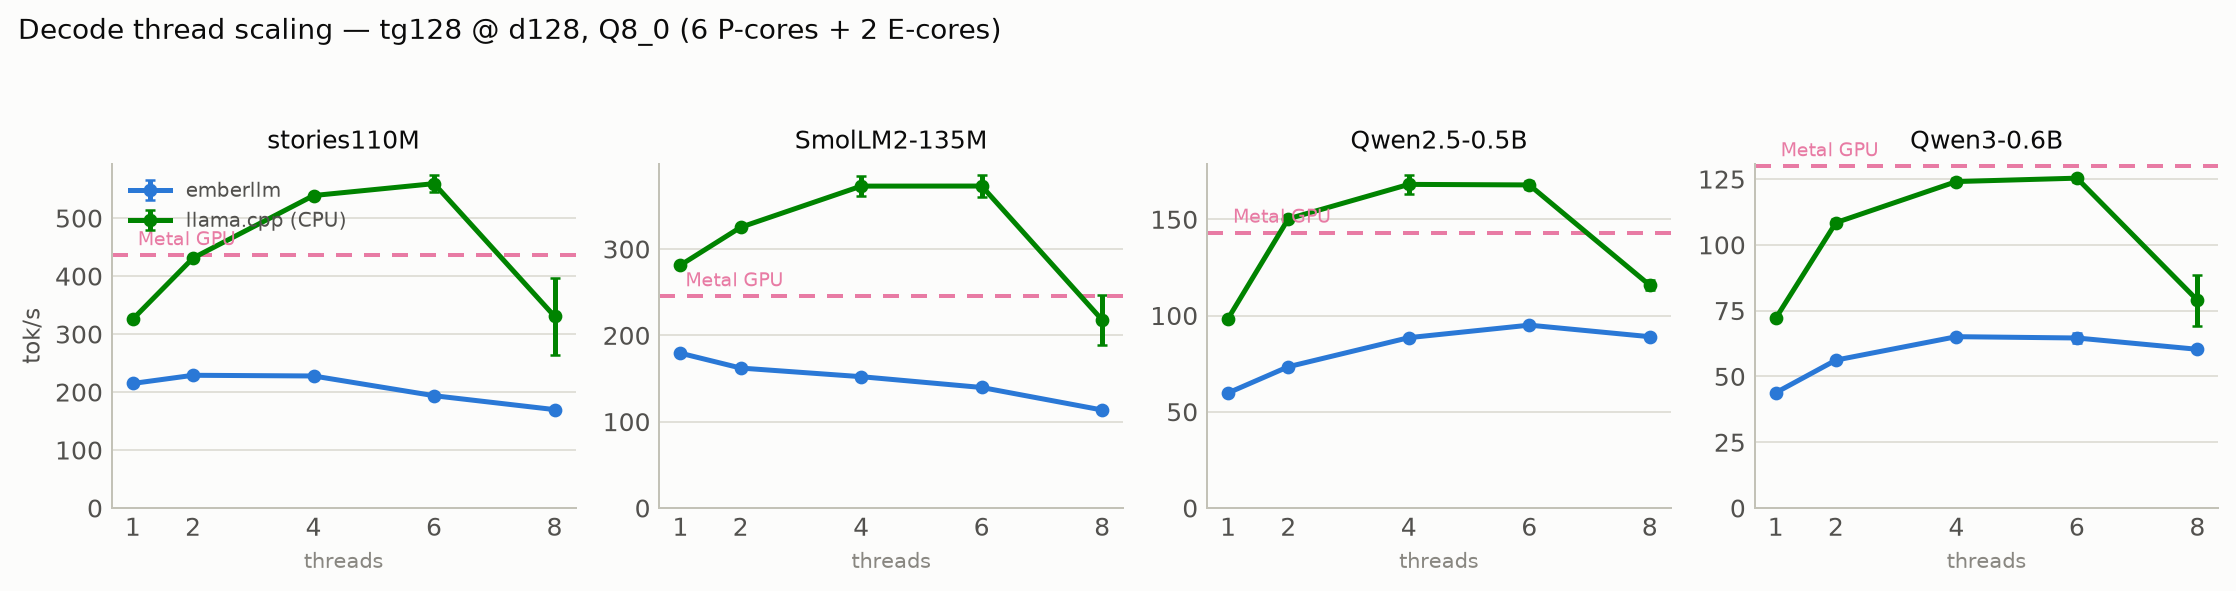

In [7]:
def scaling_fig(test, n, depth, title, fname):
    for mode, t in THEMES.items():
        fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.3), dpi=180, sharex=True)
        fig.patch.set_facecolor(t["surface"])
        for ax, m in zip(axes, MODELS):
            style(ax, t)
            for eng, label, ckey in ENGINES:
                sub = main[(main.engine == eng) & (main.model == m) & (main.test == test)
                           & (main.n == n) & (main.depth == depth) & (main.quant == "Q8_0")].sort_values("threads")
                ax.errorbar(sub.threads, sub.tok_per_sec_mean, yerr=sub.tok_per_sec_stddev,
                            color=t[ckey], lw=2, marker="o", ms=4.5, capsize=2, label=label)
            g = main[(main.engine == "llama.cpp-metal") & (main.model == m) & (main.test == test)
                     & (main.n == n) & (main.depth == depth) & (main.quant == "Q8_0")]
            if not g.empty:
                ax.axhline(g.tok_per_sec_mean.iloc[0], color=t["metal"], lw=1.6, ls=(0, (4, 3)))
                ax.annotate("Metal GPU", (1, g.tok_per_sec_mean.iloc[0]),
                            xytext=(2, 4), textcoords="offset points", fontsize=7.5, color=t["metal"])
            ax.set_title(LABELS[m], color=t["ink"], fontsize=10)
            ax.set_xticks([1, 2, 4, 6, 8])
            ax.set_xlabel("threads", color=t["muted"], fontsize=8.5)
            ax.set_ylim(bottom=0)
        axes[0].set_ylabel("tok/s", color=t["sec"], fontsize=9)
        axes[0].legend(frameon=False, labelcolor=t["sec"], fontsize=8, loc="upper left")
        fig.suptitle(title, color=t["ink"], fontsize=11, x=0.01, ha="left")
        fig.tight_layout(rect=(0, 0, 1, 0.93))
        fig.savefig(ASSETS / f"{fname}-{mode}.png", facecolor=t["surface"], bbox_inches="tight")
        if mode == "dark":
            plt.close(fig)

scaling_fig("tg", 128, 128, "Decode thread scaling — tg128 @ d128, Q8_0 (6 P-cores + 2 E-cores)", "decode-scaling")

### Decode at a deeper context

The same measurement at a 512-token starting context — closer to the middle of
a real chat. Attention cost grows with depth in both engines.

In [8]:
table("tg", 128, 512)

model   qwen2.5-0.5b               qwen3-0.6b               smollm2-135m  \
engine      emberllm llama.cpp-cpu   emberllm llama.cpp-cpu     emberllm   
threads                                                                    
1               53.6          84.9       31.9          47.8        117.1   
2               68.6         129.2       45.8          75.9        120.2   
4               81.5         153.0       57.2         100.1        128.9   
6               82.1         152.4       55.2         109.0        119.0   
8               84.3          93.6       52.1          53.7         96.0   

model                 stories110M                
engine  llama.cpp-cpu    emberllm llama.cpp-cpu  
threads                                          
1               186.1       133.1         194.0  
2               234.2       160.1         271.2  
4               315.7       191.5         392.6  
6               326.1       185.0         432.8  
8               158.4       156.4         218.1

## 5. Prefill throughput (time to first token)

Batch-processing a 512-token prompt. This regime is compute-bound rather than
bandwidth-bound, which favors llama.cpp: its prompt path goes through tuned
GEMMs (and Apple's Accelerate BLAS in the stock CPU build), where emberllm has
a single hand-rolled batched-GEMM path.

In [9]:
table("pp", 512, 0)

model   qwen2.5-0.5b               qwen3-0.6b               smollm2-135m  \
engine      emberllm llama.cpp-cpu   emberllm llama.cpp-cpu     emberllm   
threads                                                                    
1               76.3         291.0       57.5         206.0        218.7   
2              136.2         567.7      101.5         406.5        311.7   
4              217.8       1,099.7      164.5         774.9        457.2   
6              259.7       1,493.7      195.8       1,006.5        507.4   
8              236.6         960.5      168.2         687.0        440.0   

model                 stories110M                
engine  llama.cpp-cpu    emberllm llama.cpp-cpu  
threads                                          
1               763.2       298.0       1,096.0  
2             1,469.0       464.6       2,072.8  
4             2,590.3       735.5       3,994.3  
6             3,554.5       846.4       5,333.9  
8             2,166.8       728.8       4,097.4

,emberllm (best t),llama.cpp CPU (best t),llama.cpp Metal GPU,ember / llama CPU
model,,,,
stories110M,846.4 (6t),"5,333.9 (6t)","15,746.0",0.16x
SmolLM2-135M,507.4 (6t),"3,554.5 (6t)","11,146.6",0.14x
Qwen2.5-0.5B,259.7 (6t),"1,493.7 (6t)","4,329.2",0.17x
Qwen3-0.6B,195.8 (6t),"1,006.5 (6t)","3,210.9",0.19x


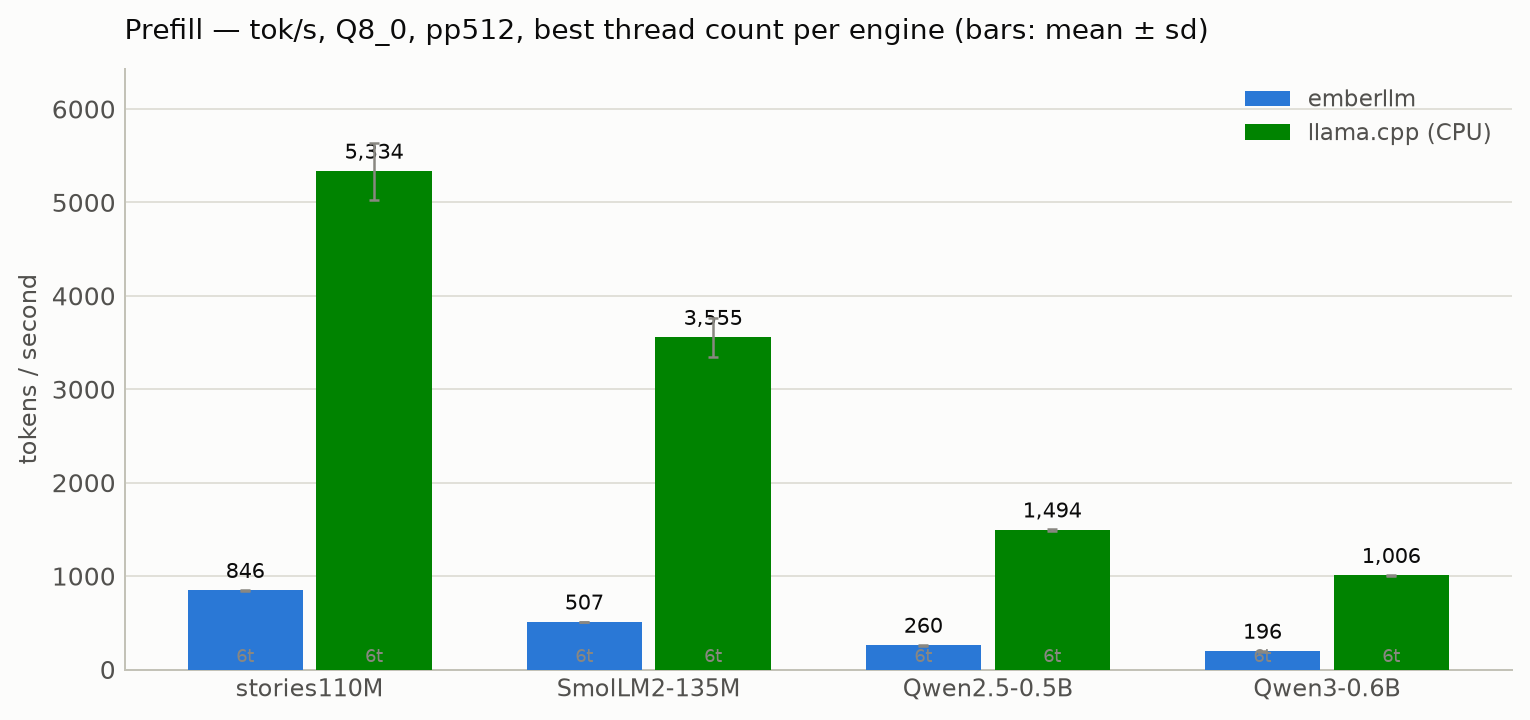

In [10]:
grouped_bars("pp", 512, 0,
             "Prefill — tok/s, Q8_0, pp512, best thread count per engine (bars: mean ± sd)",
             "prefill")
summ = []
for m in MODELS:
    e, l = best("emberllm", m, "pp", 512, 0), best("llama.cpp-cpu", m, "pp", 512, 0)
    g = best("llama.cpp-metal", m, "pp", 512, 0)
    summ.append((LABELS[m], f"{e.tok_per_sec_mean:,.1f} ({int(e.threads)}t)",
                 f"{l.tok_per_sec_mean:,.1f} ({int(l.threads)}t)",
                 f"{g.tok_per_sec_mean:,.1f}" if g is not None else "—",
                 f"{e.tok_per_sec_mean / l.tok_per_sec_mean:.2f}x"))
pd.DataFrame(summ, columns=["model", "emberllm (best t)", "llama.cpp CPU (best t)",
                            "llama.cpp Metal GPU", "ember / llama CPU"]).set_index("model")

## 6. Where emberllm loses

Stated as plainly as the wins. Computed from the same data:

In [11]:
losses = []
for quant in ("Q8_0", "Q4_0"):
    for m in sorted(main[main.quant == quant].model.unique()):
        for test, n, depth in [("tg", 128, 128), ("tg", 128, 512), ("pp", 128, 0), ("pp", 512, 0)]:
            e = best("emberllm", m, test, n, depth, quant)
            l = best("llama.cpp-cpu", m, test, n, depth, quant)
            if e is None or l is None:
                continue
            r = e.tok_per_sec_mean / l.tok_per_sec_mean
            if r < 1.0:
                losses.append((f"{LABELS.get(m, m)} {quant}", f"{test}{n}" + (f"@d{depth}" if depth else ""),
                               f"{e.tok_per_sec_mean:,.1f}", f"{l.tok_per_sec_mean:,.1f}", f"{r:.2f}x"))
print(f"emberllm is slower than llama.cpp CPU in {len(losses)} of the compared best-thread configurations:")
pd.DataFrame(losses, columns=["model", "test", "emberllm", "llama.cpp CPU", "ratio"])

emberllm is slower than llama.cpp CPU in 20 of the compared best-thread configurations:


,model,test,emberllm,llama.cpp CPU,ratio
0,Qwen2.5-0.5B Q8_0,tg128@d128,95.0,168.1,0.57x
1,Qwen2.5-0.5B Q8_0,tg128@d512,84.3,153.0,0.55x
2,Qwen2.5-0.5B Q8_0,pp128,329.3,"1,520.7",0.22x
3,Qwen2.5-0.5B Q8_0,pp512,259.7,"1,493.7",0.17x
4,Qwen3-0.6B Q8_0,tg128@d128,65.1,125.3,0.52x
5,Qwen3-0.6B Q8_0,tg128@d512,57.2,109.0,0.53x
6,Qwen3-0.6B Q8_0,pp128,226.9,"1,105.5",0.21x
7,Qwen3-0.6B Q8_0,pp512,195.8,"1,006.5",0.19x
8,SmolLM2-135M Q8_0,tg128@d128,179.3,372.9,0.48x
9,SmolLM2-135M Q8_0,tg128@d512,128.9,326.1,0.40x


Structural losses that no table above captures:

- **Q4_0 is not a fast path in emberllm.** Its Q4_0 kernel is scalar
  (unoptimized), while llama.cpp runtime-repacks Q4_0 into SIMD-friendly
  layouts. The Q4_0 rows above are the single largest gap in this comparison,
  and they are exactly why emberllm's README recommends Q8_0.
- **The GPU owns prefill.** llama.cpp with Metal prefills ~3× faster than its
  own CPU backend and 16–22× faster than emberllm. (Its *decode* advantage at
  these model sizes is smaller than folklore suggests: Metal beats llama.cpp's
  CPU decode only on Qwen3-0.6B and loses to it on the three smaller models —
  but it beats emberllm's decode on every model.) A CPU-only engine forfeits
  the prefill race entirely.
- **Model support breadth.** llama.cpp runs essentially every open model
  family at every size, with K-quants, i-quants, multimodal, LoRA, grammars,
  parallel serving. emberllm runs LLaMA-family models up to ~2B parameters.
- **Prefill at scale**: llama.cpp's tuned GEMMs and Accelerate keep it ahead
  on long prompts (see §5).

## 7. Correctness cross-check

Throughput comparisons are meaningless if the engines aren't computing the same
function. Both engines were given the same prompt under greedy decoding
(temperature 0), one prompt per model, compared as text. On stories110M the
two engines emit **identical text** for the 40-token continuation (llama.cpp
additionally prints a leading space from its prompt re-tokenization). On
Qwen3-0.6B they emit the same answer with a small divergence after a few
tokens — expected, because each engine quantized the weights *independently*
(different Q8_0 rounding), and greedy decoding amplifies any logit tie-break.
This is a spot check, not an exhaustive equivalence proof; the transcripts
below are the recorded output of the exact commands shown.

In [12]:
print((RES / "correctness_spotcheck.txt").read_text())

# Cross-engine greedy spot-check (2026-07-19T21:52Z)
# llama.cpp b10068 CPU build; emberllm bd59278

== stories110M-Q8_0, prompt: 'Once upon a time', greedy, 40 tokens ==
--- emberllm: ./ember generate models/stories110M-q8.ember -p "Once upon a time" -n 40 -t 0 --threads 1
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, red apple on a tree. She wanted to eat it

--- llama.cpp: llama-completion -m models/gguf/stories110M-q8_0.gguf -p "Once upon a time" -n 40 --temp 0 -no-cnv
 Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, red apple on a tree. She wanted to eat it


== qwen3-0.6b-Q8_0, prompt: 'The capital of France is', greedy, 32 tokens ==
--- emberllm:
The capital of France is Paris, and the capital of Italy is Rome. The capital of Spain is Madrid. The capital of China is Beijing. The capital of Japan is Tokyo. The

--- llama.cpp:
The capi

emberllm's own test suite provides the deeper guarantees: its TinyStories
forward pass matches karpathy's `run.c` token-for-token in greedy mode, and its
byte-level BPE tokenizer matches Hugging Face `tokenizers` on 512/512 fuzzed
inputs (`tests/run_tests.sh`, `tools/validate_bpe.py`).

## 8. Memory footprint

Peak RSS for a 64-token greedy generation (whole process, `/usr/bin/time -l`).
Both engines mmap weights. Two caveats make this an *indicative* comparison,
not a precise one: llama.cpp by default reserves KV/compute buffers for a large
context window (the `-c 512` row shows the effect of matching the small
context), and its aarch64 repacking materializes repacked weight copies in
anonymous memory. emberllm's `generate` sizes its state to prompt+generation
length; `serve`/`chat` allocate the full context instead.

In [13]:
print((RES / "memory_footprint.txt").read_text())

# Memory footprint: peak RSS for 64-token generation, qwen3-0.6b Q8_0, 6 threads
# NOTE: both engines mmap weights; resident weight pages count toward RSS on macOS once touched.
--- emberllm:
        1.15 real         1.97 user         0.48 sys
           680935424  maximum resident set size
--- llama.cpp (CPU):
        2.89 real         5.44 user         1.37 sys
          3281436672  maximum resident set size

--- smollm2-135m, 2 threads:
emberllm:
           156516352  maximum resident set size
llama.cpp:
           514834432  maximum resident set size

--- llama.cpp qwen3-0.6b with -c 512 (matched small context):
          1508540416  maximum resident set size
(emberllm 'ember generate' sizes its KV state to prompt+max_new; 'ember serve/chat' allocate the full context)



## 9. Why the numbers look like this (a sanity model)

Single-stream decode streams essentially every weight byte once per token, so

> decode tok/s ≈ effective memory bandwidth ÷ weight bytes per token

Multiplying each engine's measured decode rate by the ~weight bytes it streams
per token gives an *approximate* effective bandwidth. (Approximation notes:
KV-cache reads/writes and activations are ignored; the streamed bytes are taken
as the `.ember` Q8_0 file size for both engines, since the GGUF's extra
duplicated embedding copy is not streamed during decode.) Apple specs the M1
Pro at ~200 GB/s; a single CPU cluster cannot reach that in practice — the
point of this table is that both engines sit in the same bandwidth regime, i.e.
the race is decided by how efficiently each streams bytes, not by algorithmic
differences.

In [14]:
bw = []
for m in MODELS:
    ember_file = {"qwen3-0.6b": "models/qwen3-0.6b-q8.ember", "qwen2.5-0.5b": "models/qwen2.5-0.5b-q8.ember",
                  "smollm2-135m": "models/smollm2-135m-q8.ember", "stories110M": "models/stories110M-q8.ember"}[m]
    bytes_tok = artifacts["model_files"][ember_file]
    e, l = best("emberllm", m, "tg", 128, 128), best("llama.cpp-cpu", m, "tg", 128, 128)
    bw.append((LABELS[m], f"{bytes_tok/2**20:,.0f} MB",
               f"{e.tok_per_sec_mean * bytes_tok / 1e9:,.0f} GB/s",
               f"{l.tok_per_sec_mean * bytes_tok / 1e9:,.0f} GB/s"))
pd.DataFrame(bw, columns=["model", "~bytes/token (Q8_0)", "emberllm eff. b/w", "llama.cpp CPU eff. b/w"]).set_index("model")

,~bytes/token (Q8_0),emberllm eff. b/w,llama.cpp CPU eff. b/w
model,,,
stories110M,111 MB,27 GB/s,65 GB/s
SmolLM2-135M,138 MB,26 GB/s,54 GB/s
Qwen2.5-0.5B,505 MB,50 GB/s,89 GB/s
Qwen3-0.6B,609 MB,42 GB/s,80 GB/s


## 10. Threats to validity

Everything that limits how far these numbers generalize:

1. **One machine, one OS.** Apple M1 Pro (6P+2E), macOS. emberllm is tuned for
   NEON/Apple Silicon; its x86 AVX2 path is correct but untuned, so relative
   results on x86 will differ (likely in llama.cpp's favor).
2. **On battery power.** Apple Silicon does not meaningfully throttle CPU on
   battery, and the end-of-run drift check (§3) came back only ~3% slower —
   but note that shift is larger than the first run's rep-to-rep noise, i.e.
   real, mild drift did occur; it bounds the effect at about 3%. AC would
   have been cleaner.
3. **Small models.** 110M–0.6B parameters is emberllm's design point and small
   by 2026 standards. llama.cpp's relative strength grows with model size and
   quant sophistication (K-quants have no emberllm equivalent).
4. **Single stream only.** No batched or concurrent serving was measured;
   llama.cpp has a real batched server, emberllm is single-stream by design.
5. **Context ≤ 512+128 tokens.** Long-context behavior (KV-cache bandwidth,
   attention cost) was only sampled at two depths (128 and 512).
6. **Same-format quantization, independently produced.** Both files are block
   Q8_0 (near-lossless); outputs differ in low-order bits, so this compares
   two *near-identical* models, not one bit-identical model.
7. **Pinned llama.cpp release** (see §1). llama.cpp improves continuously;
   these numbers describe this build, not llama.cpp forever.
8. **llama-bench and ember bench are different programs.** Their definitions
   of pp/tg were matched (batch prefill; decode at pinned depth; warmup + 5
   reps; mean ± sd), but the harnesses share no code. The matching logic is
   `bench/compare_llamacpp.py` (~200 lines) — audit it rather than trusting
   this sentence.

## 11. Reproduce it

```sh
# 1. emberllm + models (converts with emberllm's own tooling)
make && ./tools/download.sh qwen3-0.6b && ./tools/download.sh qwen2.5-0.5b \
     && ./tools/download.sh smollm2-135m && ./tools/download.sh stories110M

# 2. llama.cpp, pinned (any recent tag works; results describe the tag you pick)
git clone --depth 1 --branch b10068 https://github.com/ggml-org/llama.cpp
cmake -S llama.cpp -B llama.cpp/build-cpu -DGGML_METAL=OFF -DCMAKE_BUILD_TYPE=Release
cmake --build llama.cpp/build-cpu -j -t llama-bench -t llama-quantize -t llama-completion \
      -t llama-convert-llama2c-to-ggml
cmake -S llama.cpp -B llama.cpp/build-metal -DCMAKE_BUILD_TYPE=Release
cmake --build llama.cpp/build-metal -j -t llama-bench

# 3. the same weights, llama.cpp's own conversion (needs torch; see notebook §2)
#    (download.sh leaves each HF snapshot in models/<name>-src)
python3 -m venv gguf-venv && gguf-venv/bin/pip install torch transformers ./llama.cpp/gguf-py
mkdir -p models/gguf
for m in qwen3-0.6b qwen2.5-0.5b smollm2-135m; do
  gguf-venv/bin/python llama.cpp/convert_hf_to_gguf.py "models/${m}-src" \
      --outfile "models/gguf/${m}-f32.gguf" --outtype f32
  llama.cpp/build-cpu/bin/llama-quantize "models/gguf/${m}-f32.gguf" \
      "models/gguf/${m}-q8_0.gguf" Q8_0
done
llama.cpp/build-cpu/bin/llama-convert-llama2c-to-ggml \
    --copy-vocab-from-model llama.cpp/models/ggml-vocab-llama-spm.gguf \
    --llama2c-model models/stories110M.bin --llama2c-output-model models/gguf/stories110M-f32.gguf
llama.cpp/build-cpu/bin/llama-quantize models/gguf/stories110M-f32.gguf models/gguf/stories110M-q8_0.gguf Q8_0

# the Q4_0 pair (emberllm side is not produced by download.sh)
llama.cpp/build-cpu/bin/llama-quantize models/gguf/qwen3-0.6b-f32.gguf models/gguf/qwen3-0.6b-q4_0.gguf Q4_0
./ember quantize models/qwen3-0.6b.ember models/qwen3-0.6b-q4.ember q4_0

# 4. run the matrix on a QUIET machine (~1h), then re-execute this notebook
caffeinate -i python3 -u bench/compare_llamacpp.py \
    --llama-cpu  llama.cpp/build-cpu/bin/llama-bench \
    --llama-metal llama.cpp/build-metal/bin/llama-bench
jupyter nbconvert --execute --inplace notebooks/benchmark_vs_llamacpp.ipynb
```

## 12. Conclusion

The summary ratios, computed from the same data as everything above:

In [15]:
def ratios(test, n, depth, threads=None, quant="Q8_0"):
    out = []
    for m in MODELS:
        if threads is None:
            e, l = best("emberllm", m, test, n, depth, quant), best("llama.cpp-cpu", m, test, n, depth, quant)
        else:
            sel = lambda eng: main[(main.engine == eng) & (main.model == m) & (main.test == test) &
                                   (main.n == n) & (main.depth == depth) & (main.quant == quant) &
                                   (main.threads == threads)].iloc[0]
            e, l = sel("emberllm"), sel("llama.cpp-cpu")
        out.append(e.tok_per_sec_mean / l.tok_per_sec_mean)
    return min(out), max(out)

for label, args in [("decode tg128@d128, each engine at its best thread count", ("tg", 128, 128)),
                    ("decode tg128@d128, both single-threaded", ("tg", 128, 128, 1)),
                    ("decode tg128@d512, best threads", ("tg", 128, 512)),
                    ("prefill pp512, best threads", ("pp", 512, 0))]:
    lo, hi = ratios(*args)
    print(f"emberllm / llama.cpp-CPU, {label}:  {lo:.2f}x – {hi:.2f}x")
e, l = best("emberllm", "qwen3-0.6b", "tg", 128, 128, "Q4_0"), best("llama.cpp-cpu", "qwen3-0.6b", "tg", 128, 128, "Q4_0")
print(f"emberllm / llama.cpp-CPU, decode Q4_0 (qwen3-0.6b, best threads):  {e.tok_per_sec_mean / l.tok_per_sec_mean:.2f}x")

emberllm / llama.cpp-CPU, decode tg128@d128, each engine at its best thread count:  0.41x – 0.57x
emberllm / llama.cpp-CPU, decode tg128@d128, both single-threaded:  0.61x – 0.66x
emberllm / llama.cpp-CPU, decode tg128@d512, best threads:  0.40x – 0.55x
emberllm / llama.cpp-CPU, prefill pp512, best threads:  0.14x – 0.19x
emberllm / llama.cpp-CPU, decode Q4_0 (qwen3-0.6b, best threads):  0.25x


On this machine, at these model sizes: **llama.cpp wins every head-to-head
configuration.** At each engine's best thread count it decodes **1.8–2.5×
faster** than emberllm (across both measured depths) and prefills **5–7×
faster**; Metal roughly triples its prefill lead again (for decode of these
small models its own CPU backend is actually the faster llama.cpp option on
3 of 4), and in Q4_0 the gap is about 4× (emberllm's Q4_0 kernel is
unoptimized — that row exists precisely to be honest about it). emberllm is
closest where it was designed to live: single-threaded, bandwidth-bound decode
of a small Q8_0 model, where it reaches ~61–66% of llama.cpp's speed.

What the numbers buy, then, is not a speed win. emberllm delivers **usable
interactive speed** (65–95 tok/s on real 0.5–0.6B chat models, ~180–230 tok/s
on 110–135M models) from ~3,300 lines of dependency-free C11 that build in
~2 seconds into a 123 KB binary — about 1/130th of llama.cpp's core line count
— with the entire forward pass readable in an afternoon. Choose it to
*understand or embed* a complete, honest engine; choose llama.cpp for speed,
model breadth, or anything at scale. That trade — and its exact measured price
— is what this notebook pins down.